<a href="https://colab.research.google.com/github/monish0705/ml_practice/blob/main/sikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from sklearn.datasets import load_breast_cancer,fetch_california_housing  # fetch helps to get the data from internet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
data=load_breast_cancer(as_frame=True).frame
data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
df=fetch_california_housing(as_frame=True).frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


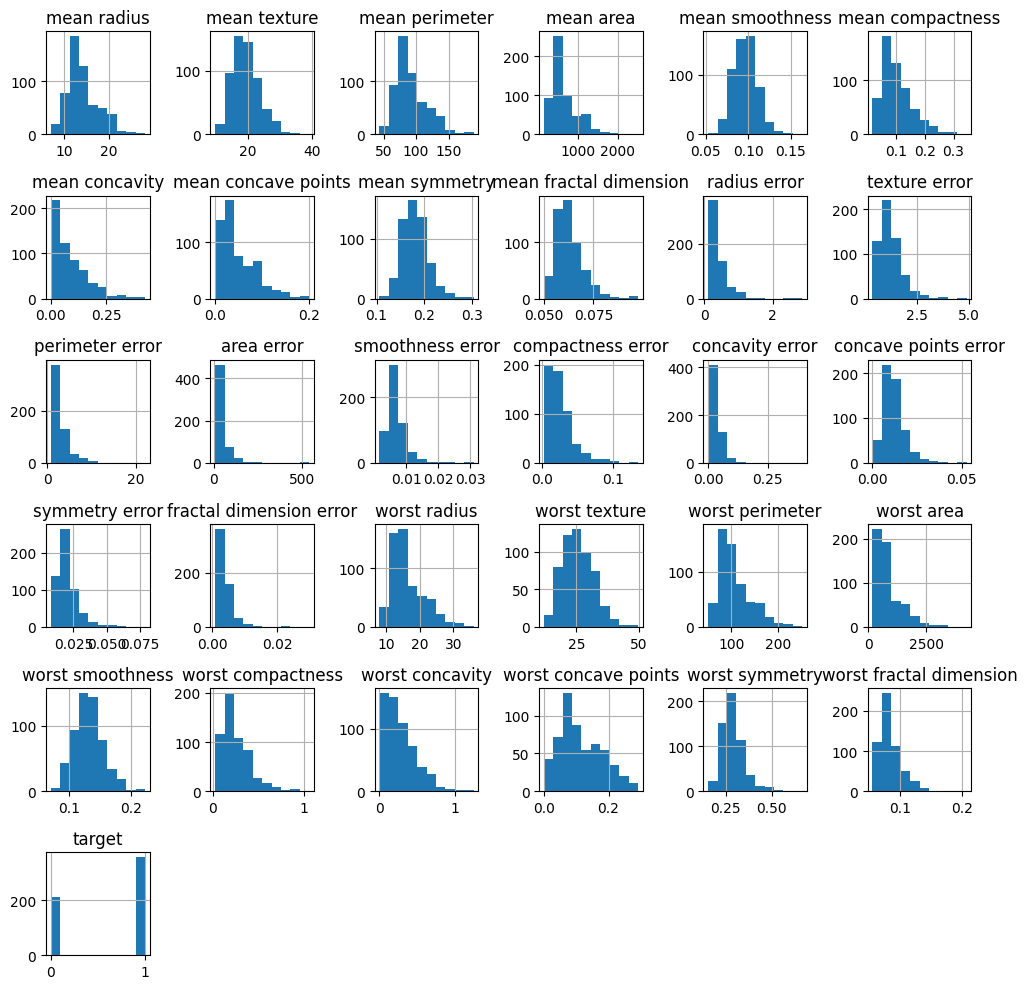

In [ ]:
data.hist(figsize=(10,10))
plt.tight_layout()

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
from sklearn.datasets import make_blobs #The make_blobs function in scikit-learn generates synthetic datasets consisting of
#isotropic Gaussian blobs, which are ideal for testing and demonstrating clustering algorithms like K-Means, DBSCAN, and Gaussian Mixture Models

In [ ]:
x,y=make_blobs()

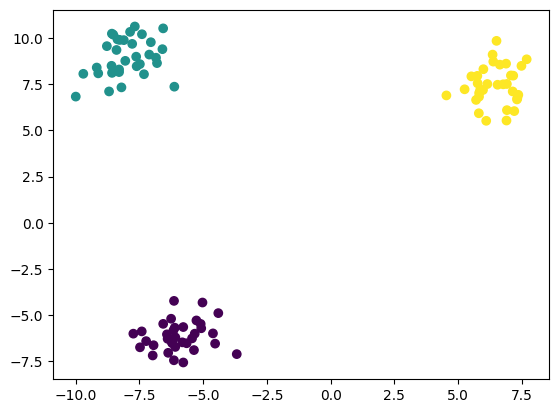

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)

In [ ]:
from sklearn.datasets import make_moons
x,y=make_moons(n_samples=500,noise=0.1)

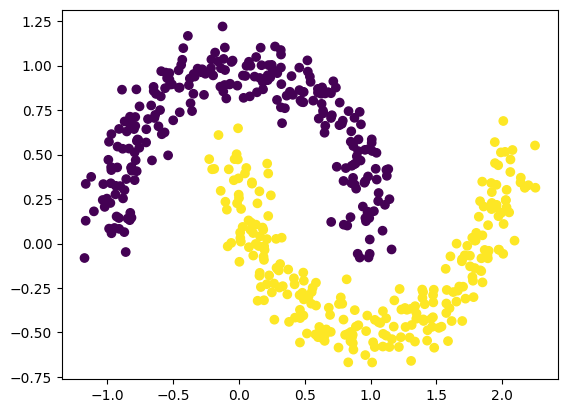

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
data=load_iris()
x,y=data.data,data.target
x_train,x_test,y_train,y_test,=train_test_split(x,y,test_size=0.2)

([<matplotlib.axis.XTick at 0x7dcd88fb56a0>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

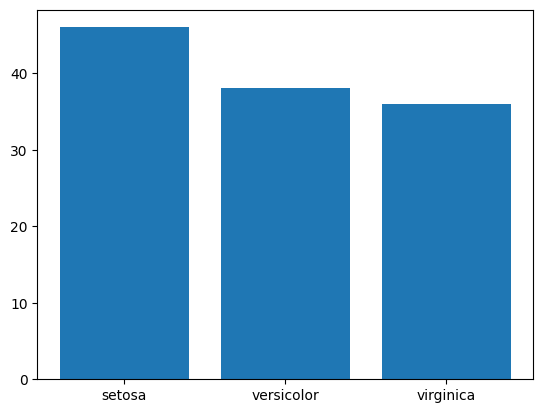

In [ ]:
import numpy as np
counts=np.bincount(y_train)
position=np.arange(3)
plt.bar(position,counts)
plt.xticks(position ,data.target_names)


([<matplotlib.axis.XTick at 0x7dcd88ff6f90>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

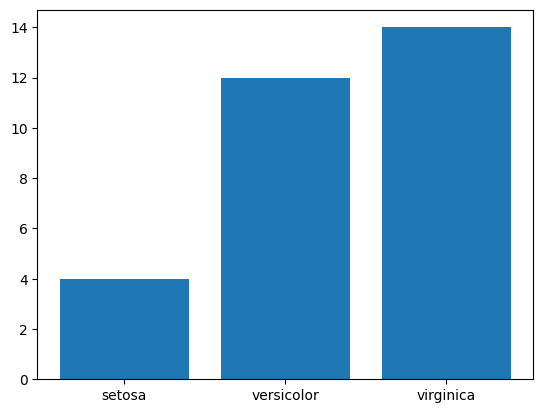

In [ ]:
import numpy as np
counts=np.bincount(y_test)
position=np.arange(3)
plt.bar(position,counts)
plt.xticks(position ,data.target_names)


In [ ]:
from sklearn.model_selection import StratifiedKFold # helps to shuffle the dataset so that it can train and p[redict the correctly
split = StratifiedKFold(n_splits=5) # Removed test_size and set n_splits to 5 for an 80/20 split
for train_idx, test_idx in split.split(x, y):
  x_train, x_test = x[train_idx], x[test_idx]
  y_train, y_test = y[train_idx], y[test_idx]

([<matplotlib.axis.XTick at 0x7dcd88e5ad50>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

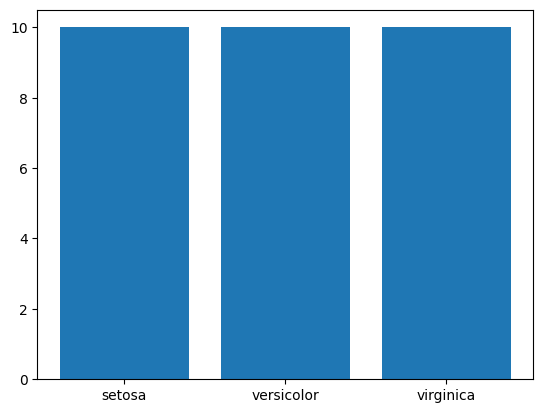

In [ ]:
import numpy as np
counts=np.bincount(y_test)
position=np.arange(3)
plt.bar(position,counts)
plt.xticks(position ,data.target_names)


In [ ]:
 scaler=StandardScaler()
 x_train_scaled=scaler.fit_transform(x_train)
 x_test_scaled=scaler.transform(x_test)

In [ ]:
x_train_scaled

array([[-9.37843750e-01,  9.84532619e-01, -1.34063266e+00,
        -1.31685196e+00],
       [-1.17527255e+00, -1.44950309e-01, -1.34063266e+00,
        -1.31685196e+00],
       [-1.41270135e+00,  3.06842862e-01, -1.39660897e+00,
        -1.31685196e+00],
       [-1.53141574e+00,  8.09462765e-02, -1.28465635e+00,
        -1.31685196e+00],
       [-1.05655815e+00,  1.21042920e+00, -1.34063266e+00,
        -1.31685196e+00],
       [-5.81700554e-01,  1.88811896e+00, -1.17270372e+00,
        -1.05126837e+00],
       [-1.53141574e+00,  7.58636033e-01, -1.34063266e+00,
        -1.18406017e+00],
       [-1.05655815e+00,  7.58636033e-01, -1.28465635e+00,
        -1.31685196e+00],
       [-1.76884454e+00, -3.70846895e-01, -1.34063266e+00,
        -1.31685196e+00],
       [-1.17527255e+00,  8.09462765e-02, -1.28465635e+00,
        -1.44964376e+00],
       [-5.81700554e-01,  1.43632579e+00, -1.28465635e+00,
        -1.31685196e+00],
       [-1.29398695e+00,  7.58636033e-01, -1.22868003e+00,
      

In [ ]:
from sklearn.preprocessing import MinMaxScaler # VALUES WILL BE CONVERTED TO 0 TO 1
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)

In [ ]:
x_train_scaled

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OrdinalEncoder
data=fetch_openml('car',as_frame=True).frame
data

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,N
1724,low,low,5more,more,med,high,N
1725,low,low,5more,more,big,low,P
1726,low,low,5more,more,big,med,N


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OrdinalEncoder

# Reload the original dataset
data = fetch_openml('car', as_frame=True).frame
#helps to onvet text to numirial values
# Define the columns to encode and their categories
columns_to_encode = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'binaryClass']
encoder = OrdinalEncoder(
    categories=[['low', 'med', 'high', 'vhigh'],  # buying
                ['low', 'med', 'high', 'vhigh'],  # maint
                ['2', '3', '4', '5more'],         # doors
                ['2', '4', 'more'],               # persons
                ['small', 'med', 'big'],          # lug_boot
                ['low', 'med', 'high'],           # safety
                ['N', 'P']]                       # binaryClass
)

# Apply the encoder to the selected columns
data[columns_to_encode] = encoder.fit_transform(data[columns_to_encode])
data

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,3.0,3.0,0.0,0.0,0.0,0.0,1.0
1,3.0,3.0,0.0,0.0,0.0,1.0,1.0
2,3.0,3.0,0.0,0.0,0.0,2.0,1.0
3,3.0,3.0,0.0,0.0,1.0,0.0,1.0
4,3.0,3.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...
1723,0.0,0.0,3.0,2.0,1.0,1.0,0.0
1724,0.0,0.0,3.0,2.0,1.0,2.0,0.0
1725,0.0,0.0,3.0,2.0,2.0,0.0,1.0
1726,0.0,0.0,3.0,2.0,2.0,1.0,0.0
